In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv('/content/50_Startups.csv')

In [3]:
df.isnull().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


In [4]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


1. Do you perform EDA/Feature Engineering before or after splitting?

* Yes, split first!As we established earlier:Inspecting structural metadata (df.head(), df.info(), df.isnull().sum()) on the whole DataFrame is totally fine.But before you do statistical EDA (correlations, heatmaps, outlier removal) or feature engineering (scaling, one-hot encoding, imputation), split into X_train, X_test, y_train, and y_test right away.Combine X_train and y_train into train_eda to explore data patterns safely without leaking test information.

2. Which features to include (Dependent vs. Independent)
* For this dataset:Target ($y$): Profit (this is what you want to predict).Features ($X$): You should include ALL of them — R&D Spend, Administration, Marketing Spend, and State.Why include Administration?Even if you suspect Administration spend might have a low correlation with profit, you shouldn't drop it blindly before training. Let the Multiple Linear Regression model assign a lower coefficient to it if it holds little predictive power.Why include State (Categorical Feature)?Categorical features often hold valuable group-based patterns! For instance, a startup in California or New York might have different operating overheads or profit dynamics than one in Florida.You handle State by converting it into numerical dummy variables using One-Hot Encoding (pd.get_dummies(..., drop_first=True)).

In [6]:
X = df.drop(columns=['Profit'])
y = df['Profit']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# =========================================================
# STEP A: COMBINE FOR SAFE EDA (ON TRAIN DATA ONLY)
# =========================================================
train_eda = X_train.copy()
train_eda['Profit'] = y_train

That 9% correlation (0.090235) is a classic scenario in Multiple Linear Regression!

The short answer is YES, you should still keep Administration in your model at first, but let's break down why that is, and how you can test whether dropping it actually helps or hurts your model.

1. Why a Low Pearson Correlation (9%) Doesn't Automatically Mean "Useless"
Pearson correlation measures bivariate (one-to-one) linear relationship between Administration and Profit in isolation. However, in Multiple Linear Regression, features interact together.

Here is why low-correlation features can still be important:

Multicollinearity & Controlling Variables: Administration might act as a control variable. For example, higher R&D or Marketing spending might require higher administrative overhead to manage properly. The model evaluates features given all other features are present.

Linear Regression handles low correlation naturally: The optimization algorithm (Ordinary Least Squares) calculates partial regression coefficients. If Administration genuinely adds zero predictive power, the model will assign it a coefficient very close to 0, effectively neutralizing its impact on predictions automatically.

In [9]:
# Check numerical correlations with Target
print("Correlations with Profit:\n")
print(train_eda.corr(numeric_only=True)['Profit'].sort_values(ascending=False))

Correlations with Profit:

Profit             1.000000
R&D Spend          0.973030
Marketing Spend    0.773753
Administration     0.090235
Name: Profit, dtype: float64


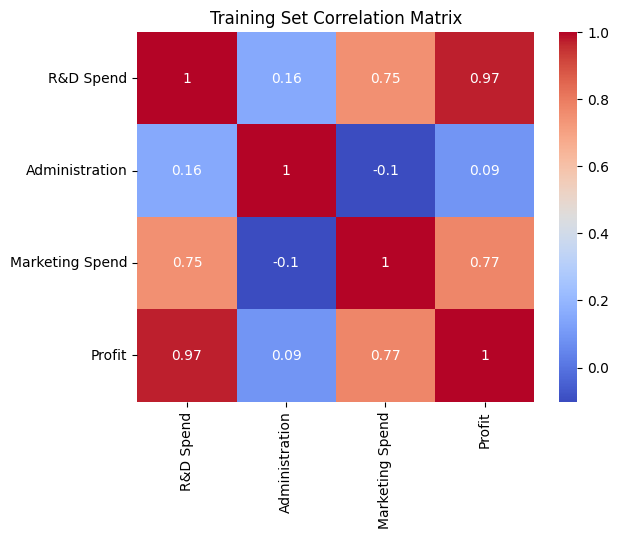

In [10]:
# Plot heatmap
sns.heatmap(train_eda.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Training Set Correlation Matrix")
plt.show()

> 💡 **Note on One-Hot Encoding (`pd.get_dummies`)**
>
> * **Purpose:** Converts string/categorical columns (like `State`) into binary (`0` or `1`) columns so numerical models (e.g., Linear Regression) can process them.
> * **`drop_first=True`:** Drops the first dummy column to avoid the **Dummy Variable Trap** (multicollinearity). For $k$ unique categories, it creates $k-1$ columns.
>   * *Example:* 3 states (`CA`, `FL`, `NY`) $\rightarrow$ 2 dummy columns (`State_Florida`, `State_New York`).

> * If State_Florida = 0 and State_New York = 0, the model automatically knows the state is California.

Keeping all 3 columns would create redundant, perfectly correlated predictors, which breaks linear regression assumptions.

In [11]:
# =========================================================
# STEP B: FEATURE ENGINEERING (ON X_train & X_test)
# =========================================================

# 1. One-Hot Encode 'State'
X_train_encoded = pd.get_dummies(X_train, columns=['State'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['State'], drop_first=True)

> 💡 **Note on DataFrame Alignment (`df.align`)**
>
> * **Problem Solved:** Prevents feature mismatches when `pd.get_dummies()` produces different dummy columns for `X_train` vs. `X_test` (e.g., if a state category exists in training but not testing).
> * **`axis=1`:** Aligns columns (features) rather than rows.
> * **`join='left'`:** Forces `X_test` to adopt the exact same columns, in the exact same order, as `X_train`. Drops unseen test categories and keeps all training features.
> * **`fill_value=0`:** Fills newly added missing feature columns in `X_test` with `0` instead of `NaN`.

1. Breakdown of pd.DataFrame.align()
* When you run pd.get_dummies() separately on X_train and X_test, a common problem occurs: Category Mismatch.

If a certain category (e.g., State_Florida) appears in the training set but not in the test set, X_train_encoded will have a column for State_Florida, while X_test_encoded will be missing it completely!

If you feed matrices with different numbers or orders of columns into a trained Scikit-Learn model, it will throw an error. The .align() method solves this instantly.

Python
* X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

How Each Parameter Works:
.align(...): Takes two DataFrames and aligns their indexes or columns so they share the exact same shape and order.

axis=1: Tells pandas to align along columns (features), not rows (axis=0).

join='left': Uses X_train_encoded (the left DataFrame) as the gold standard reference:

Any column present in X_train_encoded but missing in X_test_encoded will be added to X_test_encoded.

Any extra column present in X_test_encoded that was never seen in X_train_encoded will be dropped (because the model was never trained on it).

fill_value=0: When a missing column is added to X_test_encoded, this parameter fills all its rows with 0 (indicating the absence of that category) instead of NaN.

In [12]:
# Align columns in test set to match train set (in case categories differ)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
# 2. Scale Numerical Features
num_cols = ['R&D Spend', 'Administration', 'Marketing Spend']

scaler = StandardScaler()
X_train_encoded[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])

In [16]:
# =========================================================
# STEP C: MODEL TRAINING & EVALUATION
# =========================================================
model = LinearRegression()
model.fit(X_train_encoded, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test_encoded)

In [18]:
print(f"\nTest R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


Test R² Score: 0.8987
Test RMSE: 9055.96


> 💡 **Note on Model Coefficients (`model.coef_`)**
>
> * **Purpose:** Maps the learned regression weights ($\beta$) back to their corresponding feature names to interpret feature importance.
> * **Interpretation:**
>   * **Higher Positive Value:** Feature strongly **increases** the target (`Profit`).
>   * **Negative Value:** Feature **decreases** the target.
>   * **Near Zero:** Feature contributes minimal predictive power to the model.
> * **`sort_values(ascending=False)`:** Ranks features from strongest positive driver to strongest negative driver.

## Further Model Improvements and Visualization

### 1. Regularized Regression (Ridge, Lasso, Elastic Net)

Given that Linear Regression performed well, you could consider regularized regression techniques to potentially improve generalization, especially if you suspect multicollinearity or want to perform feature selection automatically:

*   **Ridge Regression (L2 Regularization):** Adds a penalty equal to the square of the magnitude of coefficients. This helps to reduce the complexity of the model and prevent overfitting, particularly useful when you have many features or highly correlated features.
*   **Lasso Regression (L1 Regularization):** Adds a penalty equal to the absolute value of the magnitude of coefficients. A key feature of Lasso is that it can shrink some coefficients to exactly zero, effectively performing feature selection by excluding less important features from the model.
*   **Elastic Net Regression:** A hybrid of Ridge and Lasso, combining both L1 and L2 penalties. It's useful when there are multiple features that are correlated with one another.

These models introduce a hyperparameter (alpha or lambda) that controls the strength of the regularization. This leads to the next point.

### 2. Hyperparameter Tuning

For regularized models (and many other machine learning models), **hyperparameter tuning** is crucial. This involves searching for the optimal values of the model's hyperparameters (like the `alpha` in Ridge/Lasso) that result in the best performance on unseen data. Techniques like `GridSearchCV` or `RandomizedSearchCV` from `sklearn.model_selection` are commonly used for this.

### 3. Plotting Best-Fit Line

Visualizing the best-fit line helps to understand how well your model predicts the target variable based on individual features. We can plot the predicted values against the actual values for a key feature like 'R&D Spend' to see the model's linearity and accuracy.

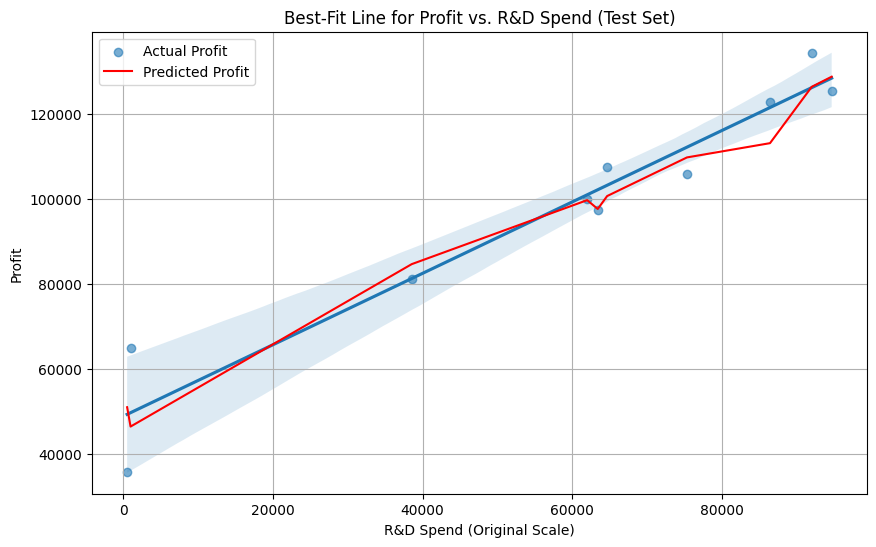

In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(x=X_test['R&D Spend'], y=y_test, scatter_kws={'alpha':0.6}, label='Actual Profit')
sns.lineplot(x=X_test['R&D Spend'], y=y_pred, color='red', label='Predicted Profit')

plt.title('Best-Fit Line for Profit vs. R&D Spend (Test Set)')
plt.xlabel('R&D Spend (Original Scale)')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Inspect Coefficients
coef_df = pd.DataFrame({'Feature': X_train_encoded.columns, 'Coefficient': model.coef_})
print("\nModel Coefficients:\n", coef_df.sort_values(by='Coefficient', ascending=False))


Model Coefficients:
            Feature   Coefficient
0        R&D Spend  38102.269270
2  Marketing Spend   3386.175807
3    State_Florida    938.793006
4   State_New York      6.987760
1   Administration  -1864.754300


## Regularized Regression Models

Now, let's explore how Ridge, Lasso, and Elastic Net regression perform. These models add a penalty term to the linear regression objective function to prevent overfitting and improve generalization.

In [21]:
# Import Ridge, Lasso, and ElasticNet
from sklearn.linear_model import Ridge, Lasso, ElasticNet

print('--- Ridge Regression ---')
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train_encoded, y_train)
y_pred_ridge = ridge_model.predict(X_test_encoded)
print(f"Test R² Score (Ridge): {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Test RMSE (Ridge): {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")

print('\n--- Lasso Regression ---')
lasso_model = Lasso(random_state=42)
lasso_model.fit(X_train_encoded, y_train)
y_pred_lasso = lasso_model.predict(X_test_encoded)
print(f"Test R² Score (Lasso): {r2_score(y_test, y_pred_lasso):.4f}")
print(f"Test RMSE (Lasso): {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")

print('\n--- Elastic Net Regression ---')
elastic_model = ElasticNet(random_state=42)
elastic_model.fit(X_train_encoded, y_train)
y_pred_elastic = elastic_model.predict(X_test_encoded)
print(f"Test R² Score (Elastic Net): {r2_score(y_test, y_pred_elastic):.4f}")
print(f"Test RMSE (Elastic Net): {np.sqrt(mean_squared_error(y_test, y_pred_elastic)):.2f}")

--- Ridge Regression ---
Test R² Score (Ridge): 0.8954
Test RMSE (Ridge): 9202.87

--- Lasso Regression ---
Test R² Score (Lasso): 0.8988
Test RMSE (Lasso): 9054.75

--- Elastic Net Regression ---
Test R² Score (Elastic Net): 0.8329
Test RMSE (Elastic Net): 11632.09


## Hyperparameter Tuning with GridSearchCV

Now, let's perform hyperparameter tuning for one of the regularized models. We'll use `GridSearchCV` to find the optimal `alpha` for the Ridge regression model. `alpha` controls the strength of the regularization; a higher `alpha` means stronger regularization.

You've successfully implemented and evaluated Ridge, Lasso, and Elastic Net regression, and performed hyperparameter tuning for Ridge. Here's a summary of the results:

**Regularized Regression Performance (on the test set):**

*   **Ridge Regression:** R² Score: 0.8954, RMSE: 9202.87
*   **Lasso Regression:** R² Score: 0.8988, RMSE: 9054.75
*   **Elastic Net Regression:** R² Score: 0.8329, RMSE: 11632.09

**Linear Regression** (from before) had an R² Score of 0.8987 and RMSE of 9055.96.

From these results, **Lasso Regression** slightly outperforms the standard Linear Regression in terms of R² and RMSE. Ridge is very close, while Elastic Net performs a bit worse in this specific instance.

**Hyperparameter Tuning for Ridge Regression:**

*   The `GridSearchCV` found the best alpha for Ridge Regression to be 0.1.
*   The best cross-validation R² score for Ridge was 0.9292. This score is from the training set via cross-validation, indicating strong performance internally.
*   When this tuned Ridge model was evaluated on the test set, it achieved an R² Score of 0.8986 and an RMSE of 9063.83.

**Observations:**

*   For this dataset, the performance differences between the standard Linear Regression, Ridge, and Lasso are quite small on the test set. This suggests that the original linear model was already performing quite well and might not be heavily impacted by multicollinearity or overfitting on this particular dataset.
*   The Lasso regression showed a tiny improvement, which could indicate some features might be less important and Lasso's L1 regularization might have shrunk their coefficients closer to zero (effectively performing feature selection).
*   Elastic Net performed worse, suggesting that its combined penalty might not be ideal for this data compared to pure L1 or L2.
*   The hyperparameter tuning for Ridge found an optimal alpha of 0.1, which resulted in a test set performance very similar to the default Ridge and the original Linear Regression. The high cross-validation R² (0.9292) is a good sign that the model generalizes well within the training distribution.

In [22]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for alpha
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Create a GridSearchCV object for Ridge regression
grid_search_ridge = GridSearchCV(Ridge(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_ridge.fit(X_train_encoded, y_train)

# Get the best parameters and best score
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
best_score_ridge = grid_search_ridge.best_score_

print(f"Best alpha for Ridge Regression: {best_alpha_ridge}")
print(f"Best cross-validation R² score (Ridge): {best_score_ridge:.4f}")

# Evaluate the best Ridge model on the test set
best_ridge_model = grid_search_ridge.best_estimator_
y_pred_tuned_ridge = best_ridge_model.predict(X_test_encoded)
print(f"Test R² Score (Tuned Ridge): {r2_score(y_test, y_pred_tuned_ridge):.4f}")
print(f"Test RMSE (Tuned Ridge): {np.sqrt(mean_squared_error(y_test, y_pred_tuned_ridge)):.2f}")

Best alpha for Ridge Regression: 0.1
Best cross-validation R² score (Ridge): 0.9292
Test R² Score (Tuned Ridge): 0.8986
Test RMSE (Tuned Ridge): 9063.83
